# Ayudantía 9: Visualización

_Ciencias de datos_

# Antes de empezar:

Si estás en un notebook local (no colab) y estás recién empezando con este tipo de cosas, es probable que tengas que instalar ciertas librerías (varía un poco dependiendo del sistema/entorno desde el que se esté ejecutando):
- [numpy](https://numpy.org/install/)
- [pandas](https://pandas.pydata.org/docs/getting_started/install.html)
- [matplotlib](https://matplotlib.org/stable/users/installing/index.html)

Generalemente basta con un  `pip install <libreria>`


## **Datos**

Utilizaremos una base de datos ya conocida para ver visualización de estos.

# Ejemplo canciones

En lo que sigue. se va a usar un _datset_ de música que se puede encontrar en [kaggle](https://www.kaggle.com/datasets/purumalgi/music-genre-classification?select=train.csv).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv("musicGenre.csv")
data

,Artist Name,Track Name,Popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Genre_name
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.000000,4,HipHop
1,Boston,Hitch a Ride,54.0,0.382,0.814,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.000000,4,Rock
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.000000,4,Indie
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.000000,4,HipHop
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.000000,4,Rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Jerry Reed,Amos Moses,45.0,0.750,0.711,-10.633,1,0.0641,0.526000,0.000653,0.0282,0.9610,105.636,2.329333,4,Country
996,The Police,Every Breath You Take - Remastered 2003,NaN,0.820,0.452,-9.796,1,0.0348,0.543000,0.002940,0.0714,0.7370,117.401,253920.000000,4,Rock
997,MOD SUN,Amnesia,58.0,0.457,0.804,-4.756,0,0.0362,0.000206,NaN,0.1970,0.5230,155.022,171033.000000,4,Pop
998,The Killers,The World We Live In,51.0,0.597,0.852,-6.890,1,0.0248,0.026500,0.004250,0.2660,0.5590,105.996,278493.000000,4,Rock


In [26]:
# Hacer que la columna de genero tenga valores categóricos
data["Genre_name"] = data["Genre_name"].astype('category')
# Asignarle un número a cada género
data["Class"] = data["Genre_name"].cat.codes
data.head(5)

,Artist Name,Track Name,Popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Genre_name,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,HipHop,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,Rock,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,Indie,6
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,HipHop,5
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,Rock,10


### Visualización de datos

Para visualizar datos podemos usar la librería pandas, que nos otorga el método ``plot``, que tiene por default un gráfico continuo de linea. Sin embargo, podemos especificar qué tipo de gráfico queremos, como por ejemeplo un gráfico de barras o de puntos.

In [4]:
# Juntamos la cantidad de artistas por género
art4gnr = data.groupby('Genre_name').count()['Artist Name'].sort_values(ascending=False)
art4gnr

Genre_name
Rock            289
Pop             154
Indie           146
Metal            91
HipHop           75
Alt              73
Blues            66
AcousticFolk     41
Instrumental     26
Country          21
Bollywood        18
Name: Artist Name, dtype: int64

#### Gráficos con pandas

<AxesSubplot:xlabel='Genre_name'>

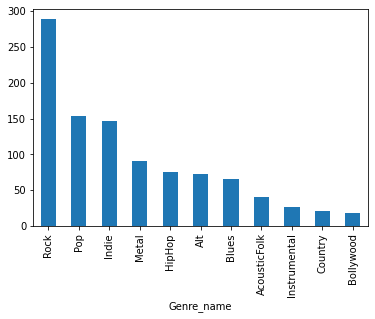

In [5]:
art4gnr.plot.bar()

<AxesSubplot:>

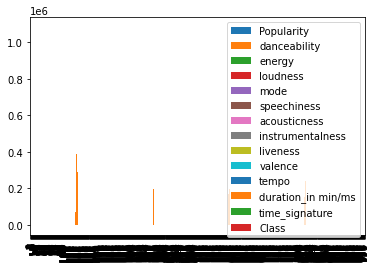

In [6]:
data.plot.bar()

#### Gráficos con MatPlotLib

Para hacer un gráfico de barra simple contando cuántos artistas hay por género, se puede usar también matplotlib, creando una figura.

Genre_name
Rock            289
Pop             154
Indie           146
Metal            91
HipHop           75
Alt              73
Blues            66
AcousticFolk     41
Instrumental     26
Country          21
Bollywood        18
Name: Artist Name, dtype: int64

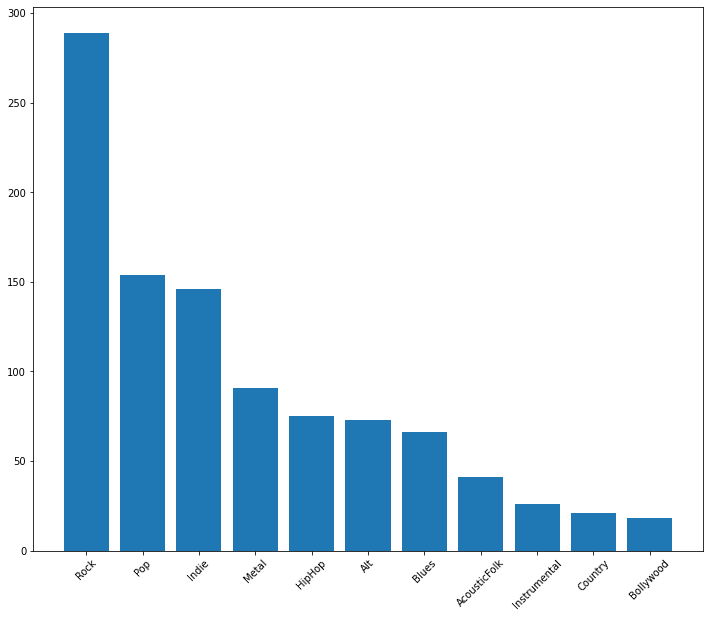

In [12]:
import matplotlib.pyplot as plt 

display(art4gnr)

# Creamos la figura
# figsize=(a,b) ajusta el tamaño
fig = plt.figure(figsize=(12,10))

# Elegimos grafico de barras (x, y)
plt.bar(art4gnr.index, art4gnr.values)
plt.xticks(rotation = 45)   # Para rotar los labels del eje x
plt.show() # Mostrar el gráfico

#fig2 = plt.figure()
#plt.scatter()

Otra forma de visualizar datos, es creando múltiples gráficos, para esto se usa la función que se mostrará a continuación.

In [13]:
# Creamos nuestros datos
dias = ['L', 'M', 'X', 'J', 'V', 'S', 'D']
temperaturas = {'Madrid':[28.5, 30.5, 31, 30, 28, 27.5, 30.5], 'Barcelona':[24.5, 25.5, 26.5, 25, 26.5, 24.5, 25]}
df = pd.DataFrame(temperaturas, index=dias)
df

,Madrid,Barcelona
L,28.5,24.5
M,30.5,25.5
X,31.0,26.5
J,30.0,25.0
V,28.0,26.5
S,27.5,24.5
D,30.5,25.0


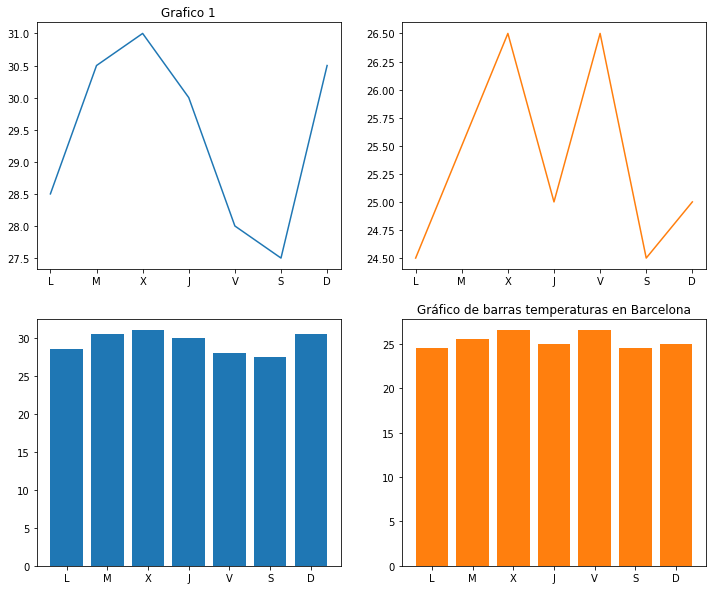

In [18]:
# Generamos una figura y sus ejes, subplots recibe una grilla en los primeros parámetros y figsize regula sus tamaños
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Agregamos los elementos del primer gráfico
ax[0, 0].plot(dias, temperaturas["Madrid"])
ax[0, 0].set_title("Grafico 1")
# Segundo gráfico
ax[0, 1].plot(dias, temperaturas['Barcelona'], color = 'tab:orange')
# Tercero
ax[1, 0].bar(dias, temperaturas['Madrid'])
# Cuarto
ax[1, 1].bar(dias, temperaturas['Barcelona'], color = 'tab:orange')
ax[1, 1].set_title("Gráfico de barras temperaturas en Barcelona")
plt.show()

Otro gráfico que es posible hacer es un scatter plot en donde seteamos x e y para graficar, el tamaño tambien lo podemos poner dependiente a una variable, en este caso sería Popularity y los colores respecto a  la clase que pertenece (género)

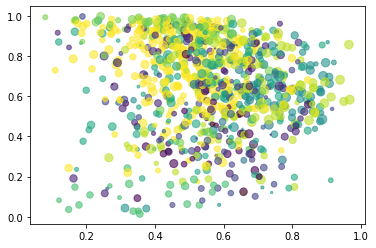

In [19]:
plt.scatter(x='danceability', y='energy', 
            alpha= 0.6,
            s=data['Popularity'], 
            c= "Class", 
            #cmap='inferno',
            #label = "Class",
            data=data)

# Actividad

1. Obtener la energía promedio por género musical.
2. Obtener el total de tiempo que hay por género en la base de datos.
3. Obtener el promedio de qué tan bailable es la música según el género.
4. Obtener cuántos artistas hay por género.
5. Graficar cada punto anterior por separado.
6. Graficar todo en un sólo gráfico.

In [20]:
data.columns

Index(['Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature',
       'Genre_name', 'Class'],
      dtype='object')

In [21]:
# 1.

nrg_mean = data.groupby(by="Genre_name").mean()["energy"]
nrg_mean

# En caso de no funcionar lo de arriba, usar .mean("energy") en vez de filtar por columna energy
# code: nrg_mean = data.groupby(by="Genre_name").mean("energy")

# En caso de que mean("energy") arroje un DataFrame completo, filtrar por columna "energy"
# code: nrg_mean = data.groupby(by="Genre_name").mean("energy")["energy"]

Genre_name
AcousticFolk    0.416266
Alt             0.686644
Blues           0.548626
Bollywood       0.537000
Country         0.600857
HipHop          0.604392
Indie           0.653856
Instrumental    0.165388
Metal           0.889791
Pop             0.603097
Rock            0.744491
Name: energy, dtype: float64

<AxesSubplot:xlabel='Genre_name'>

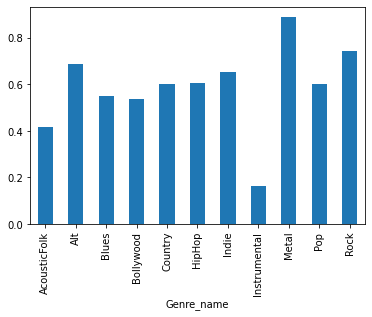

In [22]:
# pandas
nrg_mean.plot.bar()

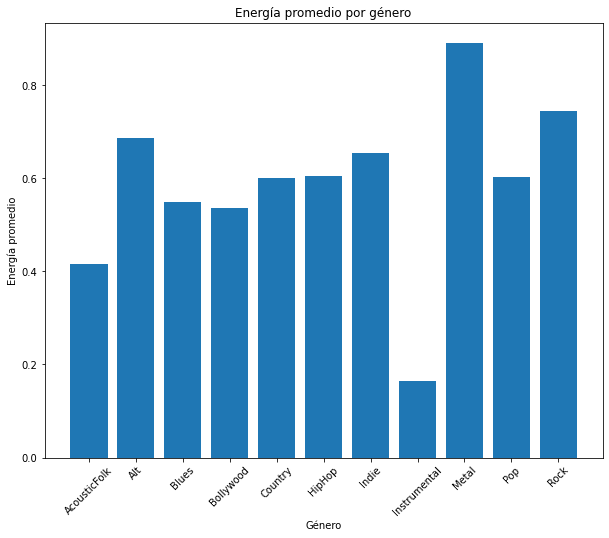

In [34]:
# Matplotlib

fig = plt.figure(figsize=(10,8))

plt.bar(nrg_mean.index, nrg_mean.values)
plt.title("Energía promedio por género")
plt.xlabel("Género")
plt.ylabel("Energía promedio")
plt.xticks(rotation=45)
plt.show()

In [36]:
# 2.

data.columns

Index(['Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature',
       'Genre_name', 'Class'],
      dtype='object')

In [37]:
time_gnr = data.groupby(by="Genre_name").sum()["duration_in min/ms"]
time_gnr

Genre_name
AcousticFolk    1.592082e+02
Alt             1.664332e+07
Blues           1.620758e+07
Bollywood       7.886970e+01
Country         6.766625e+01
HipHop          1.600705e+07
Indie           3.403467e+07
Instrumental    8.936540e+01
Metal           2.383934e+07
Pop             2.860393e+07
Rock            6.579284e+07
Name: duration_in min/ms, dtype: float64

<AxesSubplot:xlabel='Genre_name'>

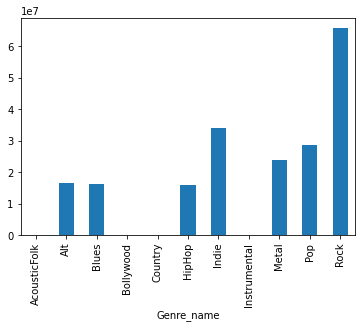

In [38]:
#Pandas
time_gnr.plot.bar()

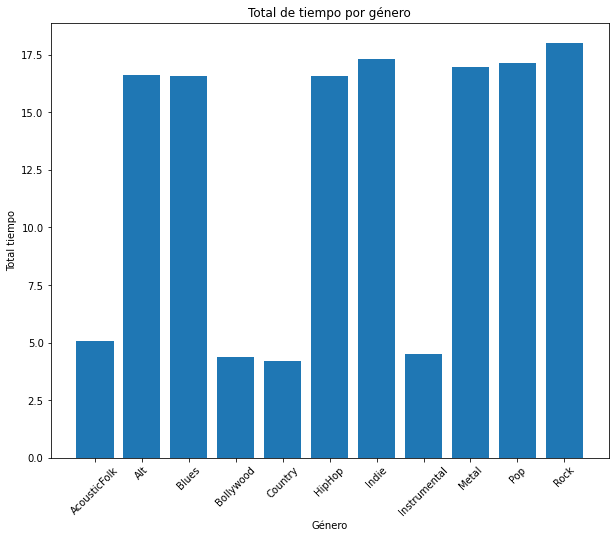

In [40]:
# Matplotlib

fig = plt.figure(figsize=(10,8))

# Graficamos una serie de pandas, no un DataFrame
plt.bar(time_gnr.index, np.log(time_gnr.values)) # Escala logarítmica para no perver barras
plt.title("Total de tiempo por género")
plt.xlabel("Género")
plt.ylabel("Total tiempo")
plt.xticks(rotation=45)
plt.show()

In [42]:
# 3.

dance_mean = data.groupby(by="Genre_name").mean()["danceability"]
dance_mean

Genre_name
AcousticFolk    0.548268
Alt             0.543192
Blues           0.579091
Bollywood       0.509333
Country         0.643524
HipHop          0.727987
Indie           0.549205
Instrumental    0.414538
Metal           0.448010
Pop             0.644805
Rock            0.494287
Name: danceability, dtype: float64

<AxesSubplot:xlabel='Genre_name'>

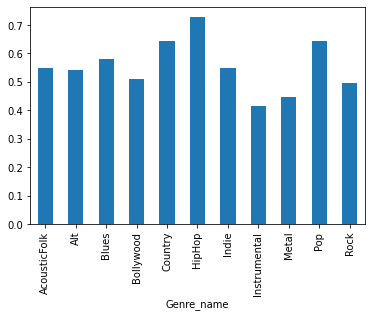

In [43]:
# Pandas
dance_mean.plot.bar()

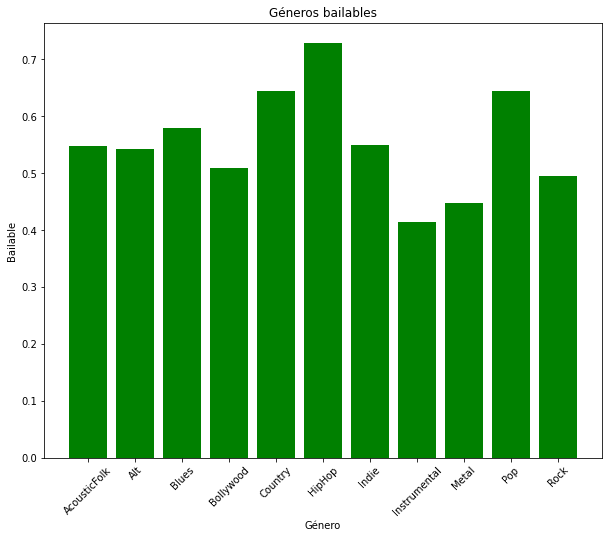

In [44]:
# Matplotlib

fig = plt.figure(figsize=(10,8))

# Graficamos una serie de pandas, no un DataFrame
plt.bar(dance_mean.index, dance_mean.values, color="g") # Escala logarítmica para no perver barras
plt.title("Géneros bailables")
plt.xlabel("Género")
plt.ylabel("Bailable")
plt.xticks(rotation=45)
plt.show()



<AxesSubplot:xlabel='Genre_name'>

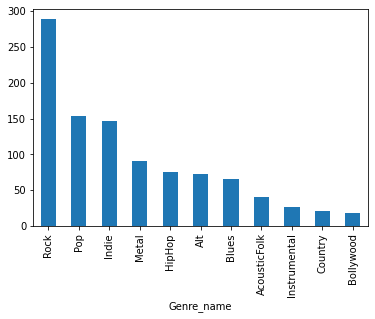

In [45]:
# 4.
art4gnr.plot.bar()

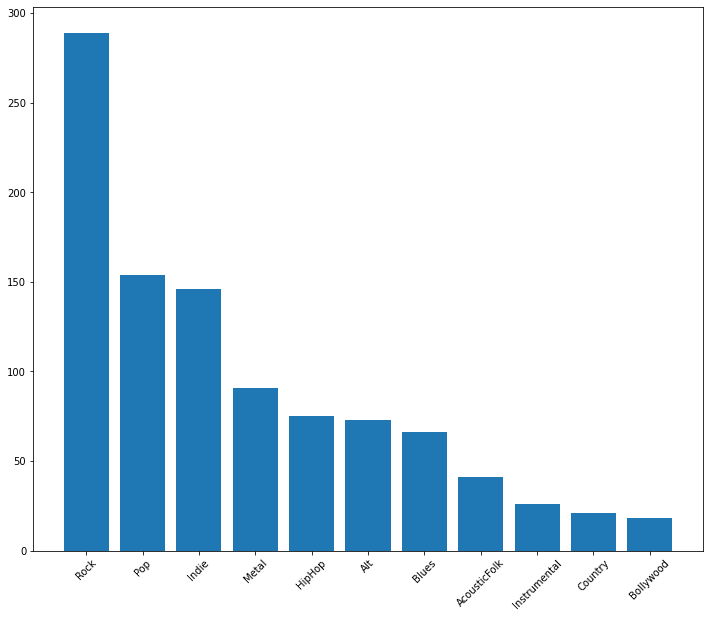

In [46]:
# Creamos la figura
# figsize=(a,b) ajusta el tamaño
fig = plt.figure(figsize=(12,10))

# Elegimos grafico de barras (x, y)
plt.bar(art4gnr.index, art4gnr.values)
plt.xticks(rotation = 45)   # Para rotar los labels del eje x
plt.show() # Mostrar el gráfico

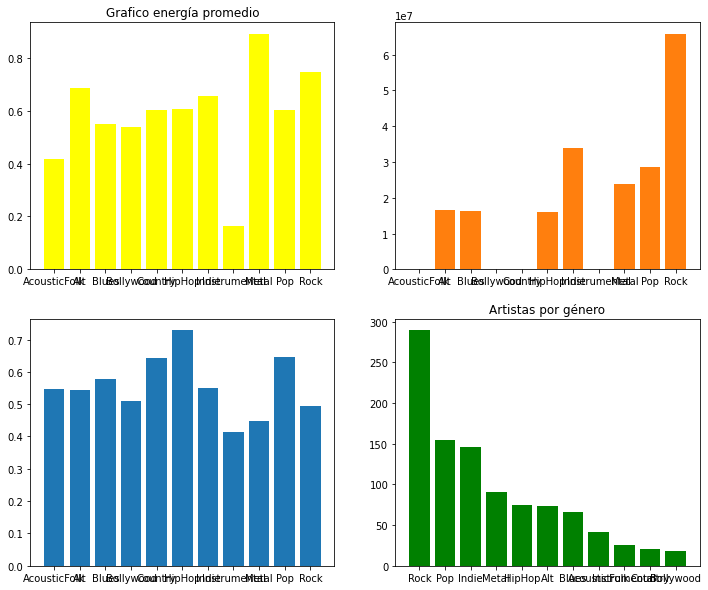

In [55]:
# 6.

# Generamos una figura y sus ejes, subplots recibe una grilla en los primeros parámetros y figsize regula sus tamaños
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Agregamos los elementos del primer gráfico
ax[0, 0].bar(nrg_mean.index, nrg_mean.values, color="yellow")
ax[0, 0].set_title("Grafico energía promedio")
# Segundo gráfico
ax[0, 1].bar(time_gnr.index, time_gnr.values, color = 'tab:orange')
# Tercero
ax[1, 0].bar(dance_mean.index, dance_mean.values)
# Cuarto
ax[1, 1].bar(art4gnr.index, art4gnr.values, color = 'green')
ax[1, 1].set_title("Artistas por género")
plt.show()